In [ ]:
import seaborn as sns
df=sns.load_dataset("taxis")

In [ ]:
#step1:load data
df.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
df.shape

(6433, 14)

In [ ]:
#step2


In [ ]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
#filling with median

for col in ['distance','fare','tip','tolls','total']:
  df[col] = df[col].fillna(df[col].median())

In [ ]:
#filling with mode

for col in ['pickup_zone','dropoff_zone','pickup_borough','dropoff_borough','payment']:
  df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
#drop rows where critical columns still have nulls

df.dropna(subset=['pickup','dropoff'],inplace=True)


In [ ]:
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


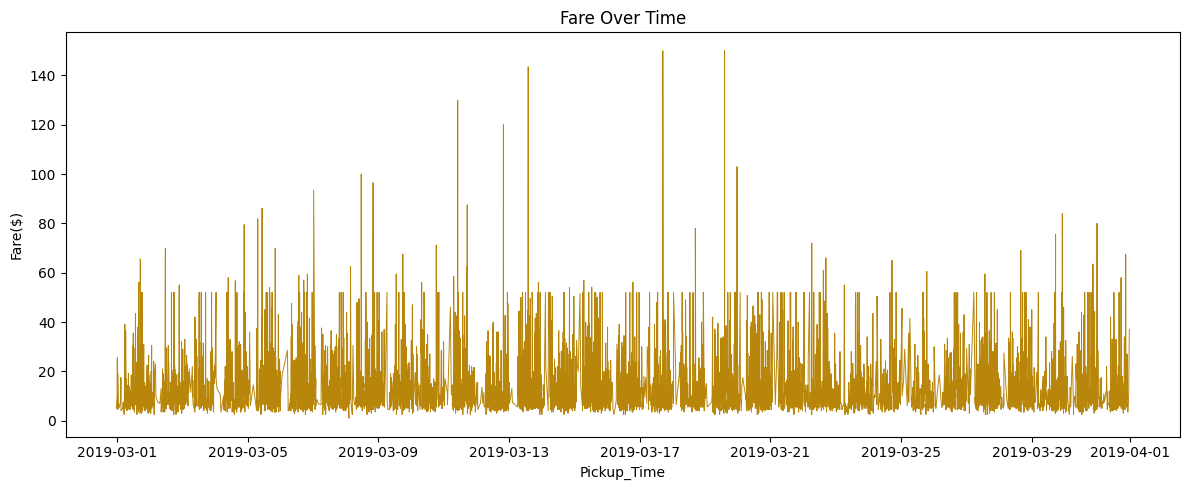

In [ ]:
#Step3: matplotlib / pandas visualisation
import pandas as pd
import matplotlib.pyplot as plt
#3.a LINE CHART fare over time

df["pickup"]= pd.to_datetime(df['pickup'])
df_sorted = df.sort_values('pickup')

plt.figure(figsize = (12,5))
plt.plot(df_sorted['pickup'],df_sorted['fare'],color='darkgoldenrod', linewidth=0.7)
plt.title('Fare Over Time')
plt.xlabel('Pickup_Time')
plt.ylabel('Fare($)')
plt.tight_layout()
plt.show()

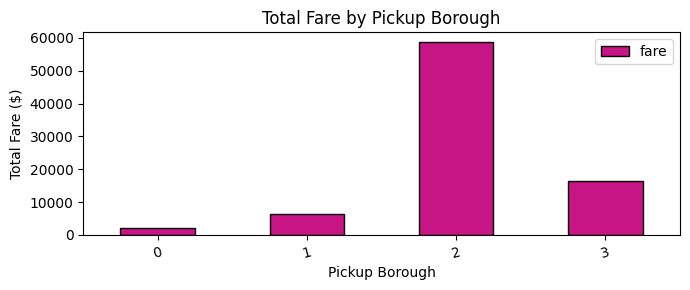

In [6]:
#3b.Bar Chart
#Total fare per Pickup Borough

borough_fare = df.groupby("pickup_borough")["fare"].sum().reset_index()
borough_fare.plot(kind="bar", figsize=(7,3) ,color ='mediumvioletred', edgecolor='black')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

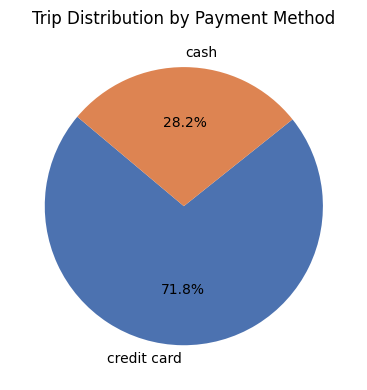

In [ ]:
#3c. Pie Chart -Trip Distribution by Payment Method

payment_counts = df['payment'].value_counts()
plt.figure(figsize=(7,4))
plt.pie(payment_counts,labels=payment_counts.index,
        autopct='%1.1f%%',startangle=140,colors =sns.color_palette('deep'))
plt.title('Trip Distribution by Payment Method')
plt.tight_layout()
plt.show()

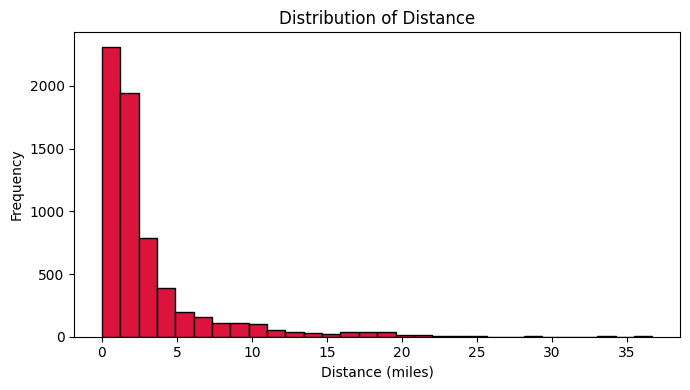

In [7]:
#3d.Histogram - Distribution of Distance

plt.figure(figsize=(7,4))
plt.hist(df["distance"],bins=30,color='crimson',edgecolor='black')
plt.title('Distribution of Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

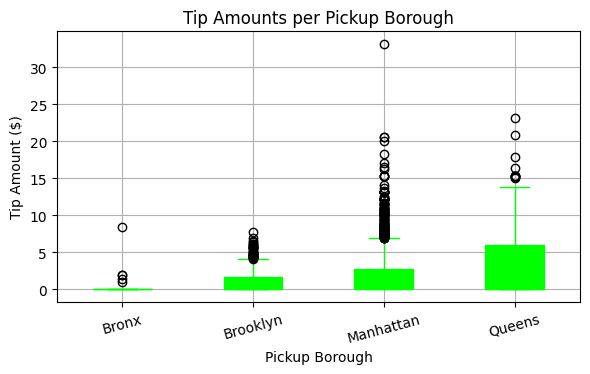

In [ ]:
#3e.BoxPlot - Tip Amount Per Pickupborugh

df.boxplot(column='tip',by='pickup_borough',
           color='lime',figsize=(6,4),patch_artist=True)

plt.title('Tip Amounts per Pickup Borough')
plt.suptitle('')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
#Step 4
#Seaborn Visualisations

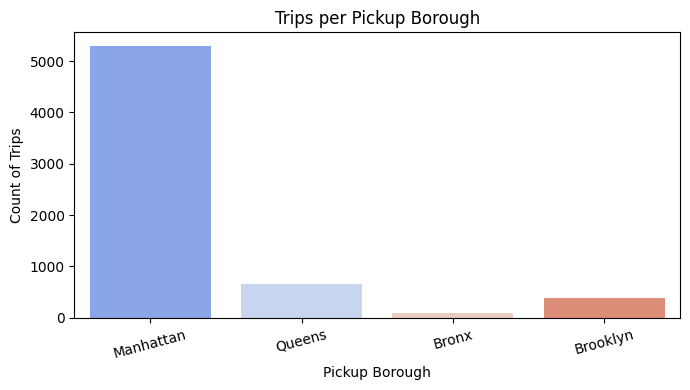

In [ ]:
#4a.CountPlot-Trips per pickup Borough

plt.figure(figsize=(7,4))
sns.countplot(data=df,x='pickup_borough',hue='pickup_borough',
              palette='coolwarm',legend=False)
plt.title('Trips per Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

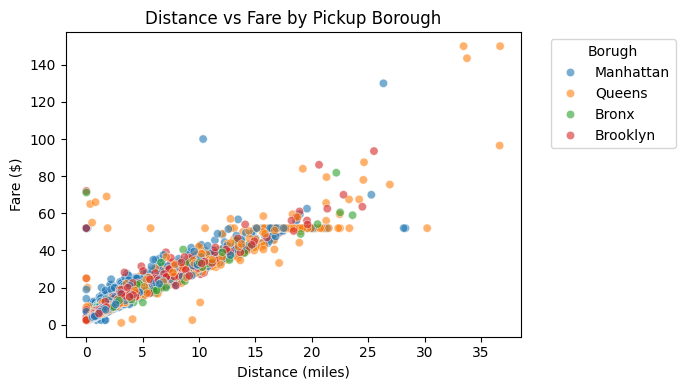

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("taxis")

#4b. ScatterPlot - Distance vs Fare


plt.figure(figsize=(7,4))
sns.scatterplot(data=df,x='distance',y='fare',hue='pickup_borough',
                palette='tab10',alpha =0.6)
plt.title('Distance vs Fare by Pickup Borough')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare ($)')
plt.legend(title='Borugh',bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

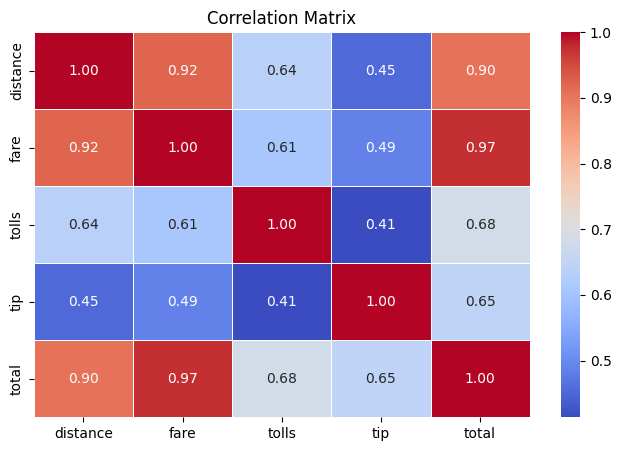

In [ ]:
#4c.Heatmap - Correlation Btw Numeric Variables

corr_cols = ['distance','fare','tolls','tip','total']
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

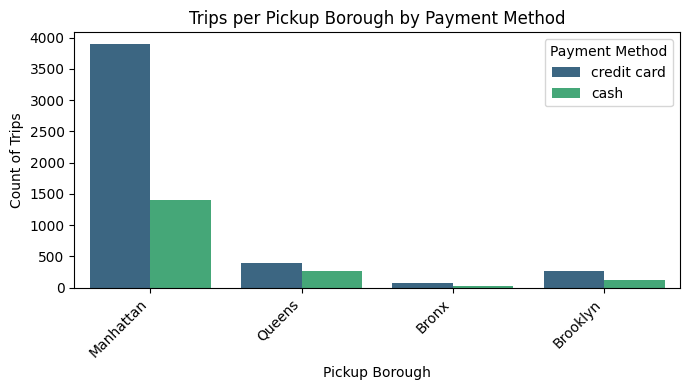

In [ ]:
#4d. CountPlot - Trips per Pickup Borough by Payment Method


plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='pickup_borough', hue='payment', palette='viridis')
plt.title('Trips per Pickup Borough by Payment Method')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Payment Method')
plt.tight_layout()
plt.show()

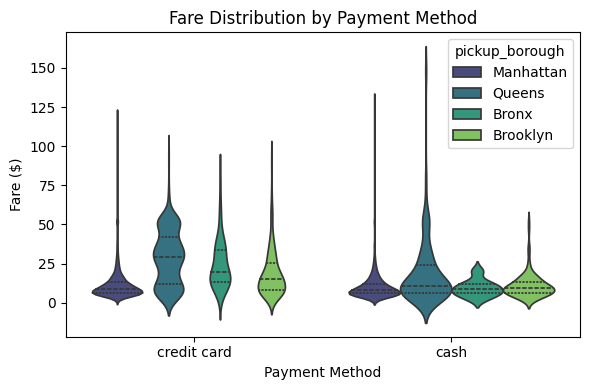

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.violinplot(data=df,x='payment',y='fare',
               hue= 'pickup_borough',palette='viridis',inner='quartile')
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.show()